# Persona C — Clasificador, N-gramas y Sentimiento

Notebook individual para probar `classifier.py`, `ngram_model.py` y `sentiment.py`
contra el dataset real, **sin tocar `main.py`**. Al final del taller, una sola
persona integra todo en `main.py`.

**Flujo de trabajo:**
1. Clonar el repo (o `git pull` si ya lo clonaste antes).
2. Instalar dependencias.
3. Cargar el dataset real con `cargar_dataset()`.
4. Probar tu parte del pipeline de forma aislada.
5. Cuando todo funcione, avisas al equipo y se integra a `main.py`.

## 1. Clonar el repositorio

Reemplaza la URL por la de su repo de GitHub. Esto descarga el proyecto completo
(incluyendo `src/`) a la máquina virtual de Colab.

In [4]:
!git clone -b BranchFrancisco https://github.com/Fifthtaschenmesser4/Taller02-ProgCien.git

Cloning into 'Taller02-ProgCien'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 75 (delta 19), reused 61 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 1.47 MiB | 10.01 MiB/s, done.
Resolving deltas: 100% (19/19), done.


Si ya lo habías clonado en una sesión anterior de Colab y solo quieres traer
los cambios más recientes de tus compañeros, usa esto en vez del clone:

```python
%cd /content/biblical_text_mining
!git pull
```

In [2]:
%cd /content/Taller02-ProgCien
!git pull

[Errno 2] No such file or directory: '/content/Taller02-ProgCien'
/content
fatal: not a git repository (or any of the parent directories): .git


## 2. Instalar dependencias

In [6]:
!pip install -q -r /content/Taller02-ProgCien/requirements.txt

## 3. Dataset

El dataset de Kaggle (`oswinrh/bible`) pesa pocos MB, así que **lo más simple es
subirlo directo al repo** dentro de `data/` y listo (cada persona lo tiene al hacer
`git clone`/`git pull`).

Si prefieren no subirlo a GitHub, otra opción es subir los 3 CSV manualmente en
cada sesión de Colab con el panel de archivos de la izquierda (ícono de carpeta),
arrastrándolos a `biblical_text_mining/data/`.

In [8]:
%cd /content/Taller02-ProgCien

/content/Taller02-ProgCien


In [9]:
from pathlib import Path
from src.dataloader import cargar_dataset
from src.models import Biblia

dir_dataset = Path("data")
path_bible = dir_dataset / "t_asv.csv"
path_key = dir_dataset / "key_english.csv"
path_genre = dir_dataset / "key_genre_english.csv"

df_raw = cargar_dataset(path_bible, path_key, path_genre)
df_raw.head()

,Verse ID,Book,Chapter,Verse,Text,Book Name,Testament (OT or NT),Genre ID,Genre name
0,1001001,1,1,1,In the beginning God created the heavens and t...,Genesis,OT,1,Law
1,1001002,1,1,2,And the earth was waste and void; and darkness...,Genesis,OT,1,Law
2,1001003,1,1,3,"And God said, Let there be light: and there wa...",Genesis,OT,1,Law
3,1001004,1,1,4,"And God saw the light, that it was good: and G...",Genesis,OT,1,Law
4,1001005,1,1,5,"And God called the light Day, and the darkness...",Genesis,OT,1,Law


In [10]:
biblia = Biblia.from_dataframe(
    df_raw,
    col_libro="Book Name",
    col_testamento="Testament (OT or NT)",
    col_capitulo="Chapter",
    col_versiculo="Verse",
    col_texto="Text",
    col_genero="Genre name",
)
print(biblia)
print(biblia.get_resumen())
print(biblia.get_resumen_generos())

df = biblia.to_dataframe()
df.head()

Biblia (66 libros, 31103 versiculos)
  testamento  n_libros  n_versiculos
0         OT        39         23145
1         NT        27          7958
        genero  n_libros  n_versiculos
0         Acts         1          1007
1  Apocalyptic         1           404
2     Epistles        21          2768
3      Gospels         4          3779
4      History        12          7018
5          Law         5          5852
6     Prophets        17          5490
7       Wisdom         5          4785


,testamento,libro,genero,capitulo,versiculo,texto_original,texto_procesado,texto_limpio
0,OT,Genesis,Law,1,1,In the beginning God created the heavens and t...,[],
1,OT,Genesis,Law,1,2,And the earth was waste and void; and darkness...,[],
2,OT,Genesis,Law,1,3,"And God said, Let there be light: and there wa...",[],
3,OT,Genesis,Law,1,4,"And God saw the light, that it was good: and G...",[],
4,OT,Genesis,Law,1,5,"And God called the light Day, and the darkness...",[],


## 4. Preprocesamiento y TF-IDF

Necesitas esto como insumo para el clasificador (features) y para el generador
de n-gramas (texto tokenizado). Esta parte la hace Persona A / B, pero la
ejecutas aquí también para poder probar tu propio módulo de forma aislada.

In [11]:
from src.preprocessing import TextPreprocessor
from src.tfidf import TFIDFVectorizer

preprocessor = TextPreprocessor()
df["texto_procesado"] = preprocessor.process_corpus(df["texto_original"].tolist())

vectorizer = TFIDFVectorizer()
matriz_tfidf = vectorizer.fit_transform(df["texto_procesado"].tolist())
matriz_tfidf.shape

(31103, 12319)

In [21]:
#TEXTO TOKENIZADO, PUESTO EN MINÚSCULAS
print(df["texto_procesado"][0])

['in', 'the', 'beginning', 'god', 'created', 'the', 'heavens', 'and', 'the', 'earth']
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, T

## 5. Clasificador de versículos (`classifier.py`)

In [24]:
from src.classifier import VerseClassifier
#1. Logistic Regression
clasificador = VerseClassifier(modelo="logistic")
#2. Naive Bayes.
#clasificador = VerseClassifier(modelo="naive_bayes")

clasificador.entrenar(matriz_tfidf, df["libro"])
resultados = clasificador.evaluar()

print(clasificador)
print("Accuracy:", resultados["accuracy"])
print(resultados["reporte"])

VerseClassifier(modelo=naive_bayes, clases=['1 Chronicles' '1 Corinthians' '1 John' '1 Kings' '1 Peter' '1 Samuel'
 '1 Thessalonians' '1 Timothy' '2 Chronicles' '2 Corinthians' '2 John'
 '2 Kings' '2 Peter' '2 Samuel' '2 Thessalonians' '2 Timothy' '3 John'
 'Acts' 'Amos' 'Colossians' 'Daniel' 'Deuteronomy' 'Ecclesiastes'
 'Ephesians' 'Esther' 'Exodus' 'Ezekiel' 'Ezra' 'Galatians' 'Genesis'
 'Habakkuk' 'Haggai' 'Hebrews' 'Hosea' 'Isaiah' 'James' 'Jeremiah' 'Job'
 'Joel' 'John' 'Jonah' 'Joshua' 'Jude' 'Judges' 'Lamentations' 'Leviticus'
 'Luke' 'Malachi' 'Mark' 'Matthew' 'Micah' 'Nahum' 'Nehemiah' 'Numbers'
 'Obadiah' 'Philemon' 'Philippians' 'Proverbs' 'Psalms' 'Revelation'
 'Romans' 'Ruth' 'Song of Solomon' 'Titus' 'Zechariah' 'Zephaniah'])
Accuracy: 0.3091142903070246
                 precision    recall  f1-score   support

   1 Chronicles       0.67      0.45      0.54       188
  1 Corinthians       0.75      0.07      0.13        87
         1 John       0.00      0.00      0.00  

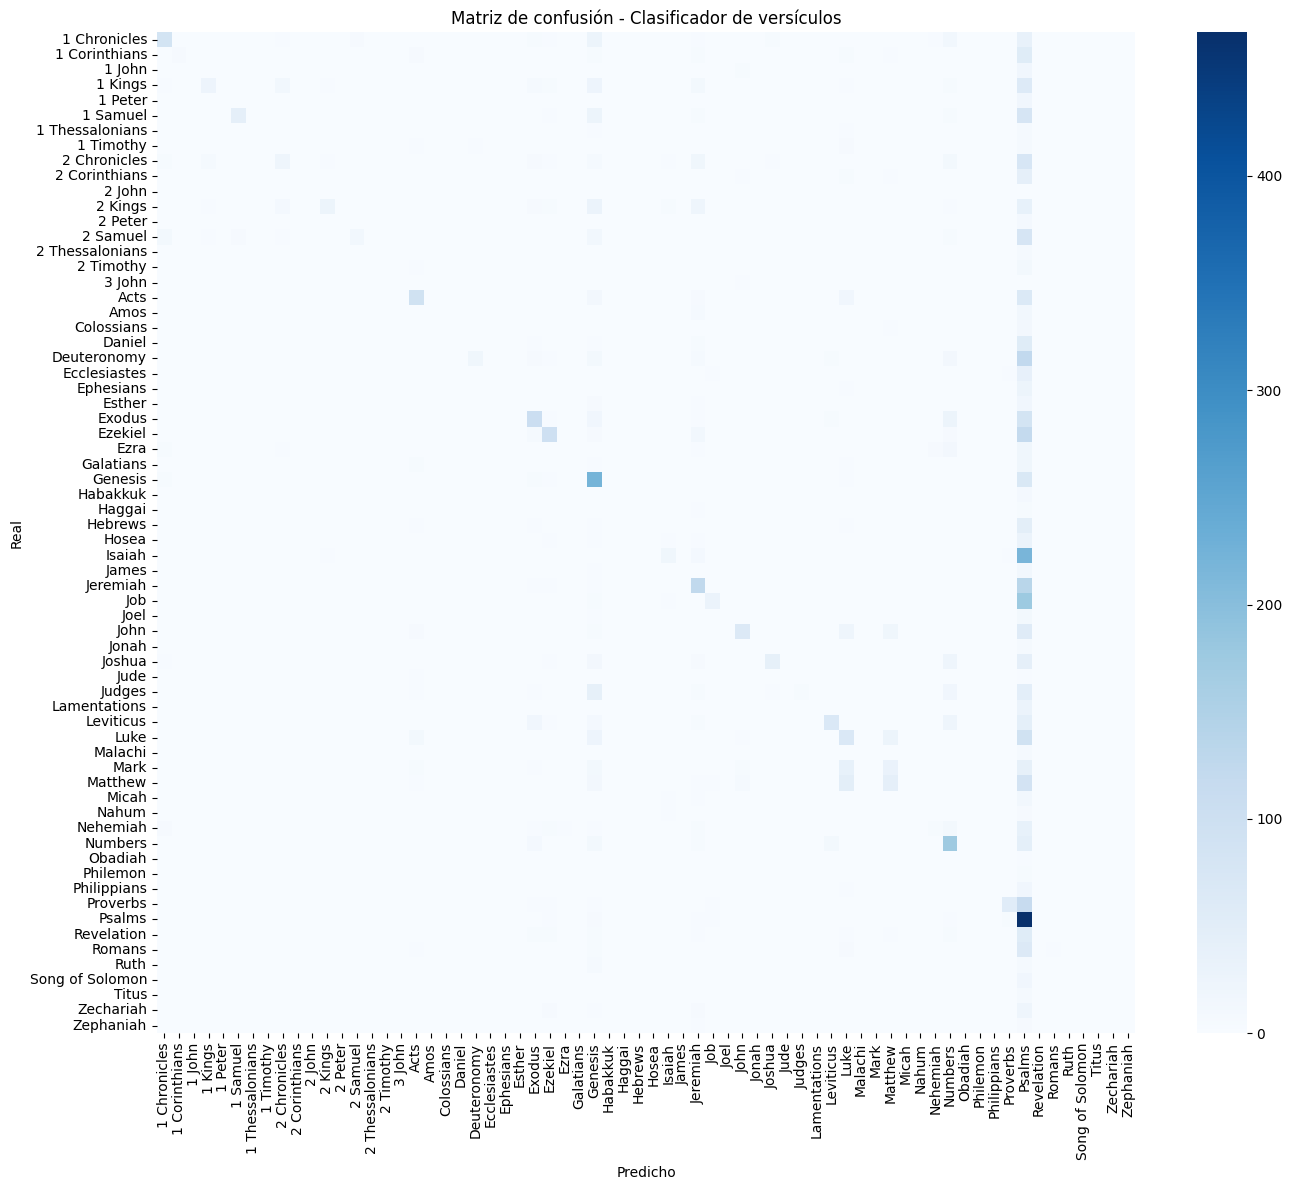

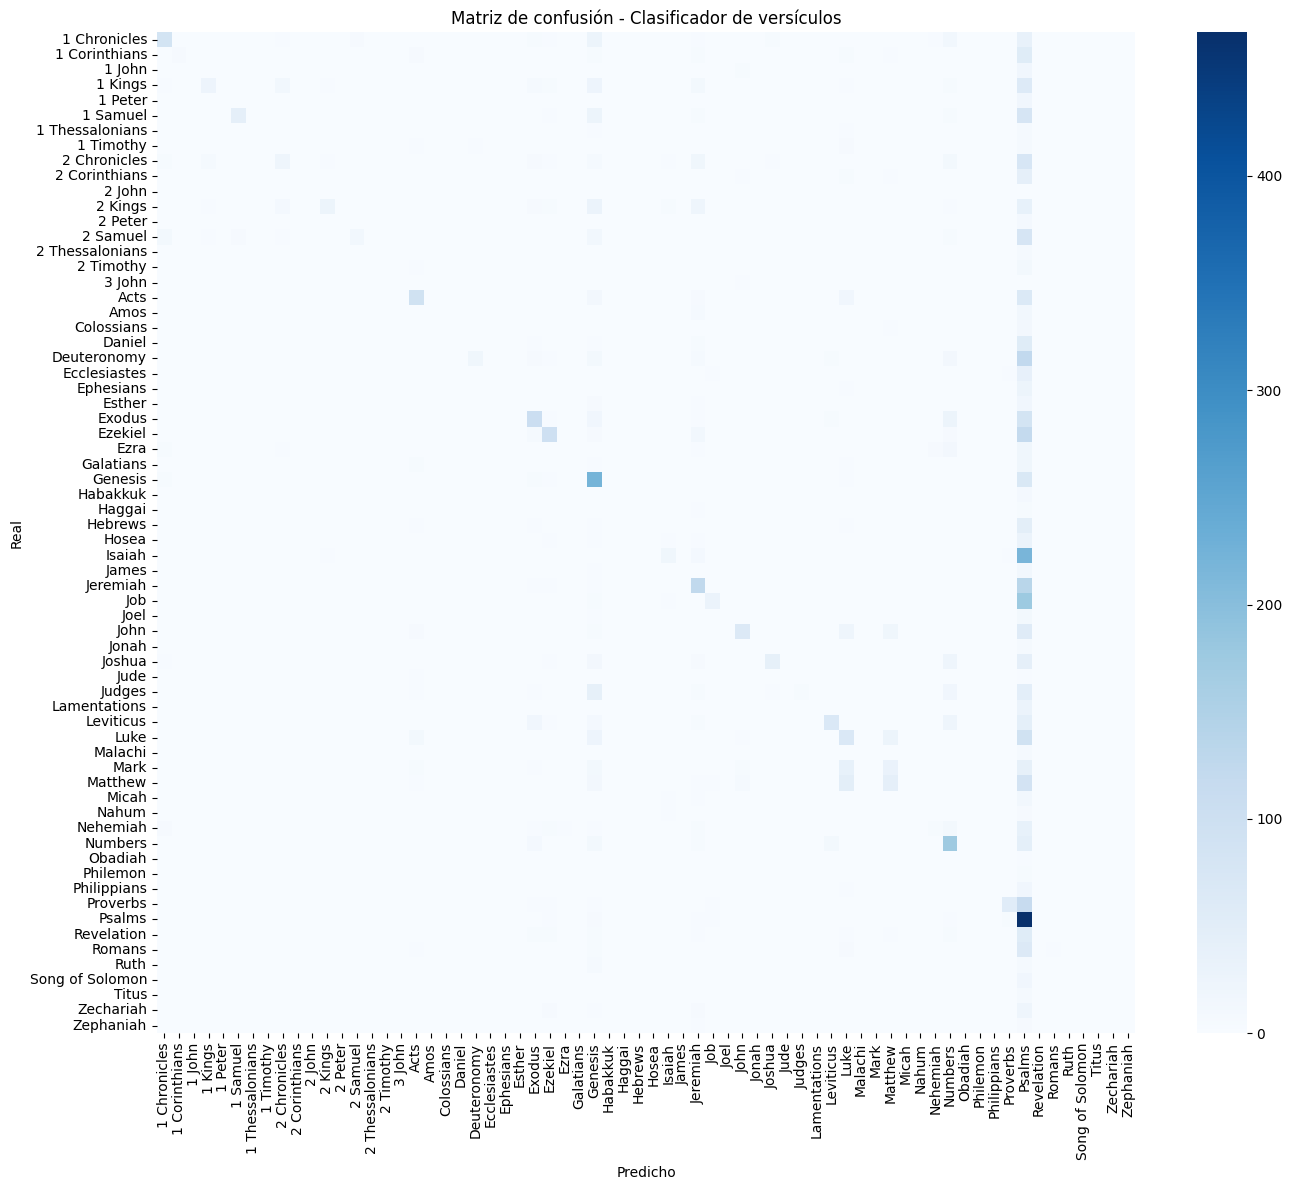

In [25]:
# Matriz de confusión (usa visualization.py si ya está disponible)
from src import visualization as viz

viz.plot_matriz_confusion(resultados["matriz_confusion"], resultados["clases"])

## 6. Generador de texto con n-gramas (`ngram_model.py`)

In [28]:
from src.ngram_model import NGramModel, comparar_modelos

resultados_ngram = comparar_modelos(list(df["texto_procesado"]), ns=(1, 2, 3, 4), max_len=20)
for n, texto in resultados_ngram.items():
    print(f"{n}-Gram: {texto}")

1-Gram: midnight lord that fuller rhoda of the and of made art went word unto cometh five the lead passed and
2-Gram: and why hast thou forget jehovah ye tempted of sincerity and your god and look on the lowly even unto
3-Gram: and the king of bashan
4-Gram: and he shall worship at the threshold of the house of israel are mine both man and beast and they


In [36]:
# Probar un modelo individual, empezando desde una palabra específica
import numpy as np
trigram = NGramModel(4).fit(list(df["texto_procesado"]))
print(trigram)
print("Generar a partir de palabra ingresada: ")
print(trigram.generar(palabra_inicial="jehovah", max_len=20))
print("Generar a partir de palabra aleatoria de los versículos: ")
print(trigram.generar(palabra_inicial=None, max_len=20))

NGramModel(n=4, vocabulario=12319 palabras)
Generar a partir de palabra ingresada: 
jehovah thou hast searched and known
Generar a partir de palabra aleatoria de los versículos: 
it is time he should not see death and he be jealous of his wife abigail and the sons of


## 7. Análisis de sentimiento (`sentiment.py`)

In [ ]:
from src.sentiment import LexiconSentimentAnalyzer, calcular_sentimiento_corpus, agregar_por_libro, agregar_por_capitulo

analizador = LexiconSentimentAnalyzer()
df = calcular_sentimiento_corpus(df, analizador)

sentimiento_libro = agregar_por_libro(df)
sentimiento_capitulo = agregar_por_capitulo(df)

sentimiento_libro.head(10)

In [ ]:
viz.plot_sentimiento_por_libro(sentimiento_libro)

## 8. Notas para subir tus cambios

Si modificaste algún archivo de `src/` (ej. ajustaste el lexicón de
`sentiment.py`), desde Colab puedes hacer commit y push directo:

```python
!git config --global user.email "tu_correo@ucn.cl"
!git config --global user.name "Tu Nombre"
!git add src/sentiment.py notebooks/persona_c.ipynb
!git commit -m "Ajusta lexicon de sentimiento y agrega pruebas"
!git push
```

Para que el `push` funcione necesitas autenticarte (ej. con un Personal Access
Token de GitHub en vez de tu contraseña). Si prefieren algo más simple,
también pueden simplemente descargar este notebook (`Archivo > Descargar > .ipynb`)
y subirlo a GitHub manualmente desde la web.

**Importante:** como cada persona trabaja en su propio notebook
(`persona_a.ipynb`, `persona_b.ipynb`, `persona_c.ipynb`), no debería haber
conflictos de Git entre ustedes. El único momento de integración real es
cuando alguien copie las piezas ya probadas a `main.py`.

In [40]:
!git config --global user.email "frome004@gmail.com"
!git config --global user.name "Fifthtaschenmesser4"
!git commit -m "notebook updating"

On branch BranchFrancisco
Your branch is up to date with 'origin/BranchFrancisco'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   src/__pycache__/__init__.cpython-312.pyc
	modified:   src/__pycache__/classifier.cpython-312.pyc
	modified:   src/__pycache__/models.cpython-312.pyc
	modified:   src/__pycache__/ngram_model.cpython-312.pyc
	modified:   src/__pycache__/preprocessing.cpython-312.pyc
	modified:   src/__pycache__/search_engine.cpython-312.pyc
	modified:   src/__pycache__/sentiment.cpython-312.pyc
	modified:   src/__pycache__/tfidf.cpython-312.pyc
	modified:   src/__pycache__/visualization.cpython-312.pyc

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	src/__pycache__/dataloader.cpython-312.pyc

no changes added to commit (use "git add" and/or "git commit -a")
